# Importación de las librerías necesarias para la ejecución #

In [1]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

from scipy.stats import f_oneway
from scipy.stats import kendalltau, spearmanr
from scipy.stats import pointbiserialr

# Lectura de los datos de los partidos ya formateados en .csv

In [2]:
import os

dataframes = []
carpeta = "Datos_Formateados/"  # Reemplaza "ruta/de/la/carpeta" con la ruta de la carpeta que deseas explorar

archivos = os.listdir(carpeta)
for archivo in archivos:
    df = pd.read_csv("Datos_Formateados/"+archivo)
    df.fillna(0,inplace=True)
    dataframes.append(df)
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.fillna(0, inplace=True)
datos_partidos.shape

with pd.ExcelWriter('Datos_Tenis_Completo.xlsx') as writer:
    archivos = os.listdir("Ejemplos/")
    i = 0
    for archivo in archivos:
        df = pd.read_csv("Ejemplos/"+archivo)
        df.to_excel(writer, sheet_name=f'Página {i+1}', index=False)
        i += 1

In [3]:
datos_partidos.head()

,Tournament,Date,Series,Court,Surface,Round,P,S,PRank,SRank,...,S2,P3,S3,P4,S4,P5,S5,Psets,Ssets,Gana_P
0,Australian Open,16/01/06,Grand Slam,Outdoor,Hard,1st Round,Melzer J.,Ginepri R.,55.0,18.0,...,6.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
1,Australian Open,16/01/06,Grand Slam,Outdoor,Hard,1st Round,Gaudio G.,Sabau R.,10.0,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,Australian Open,16/01/06,Grand Slam,Outdoor,Hard,1st Round,Serra F.,Ferrer D.,37.0,14.0,...,6.0,1.0,6.0,4.0,6.0,0.0,0.0,1.0,3.0,0.0
3,Australian Open,16/01/06,Grand Slam,Outdoor,Hard,1st Round,Schuettler R.,Burgsmuller L.,87.0,143.0,...,6.0,6.0,7.0,3.0,6.0,0.0,0.0,1.0,3.0,0.0
4,Australian Open,16/01/06,Grand Slam,Outdoor,Hard,1st Round,Bracciali D.,Lu Y.H.,80.0,161.0,...,6.0,6.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0


In [4]:
def get_tenistas(dataframe: pd.DataFrame) -> list:
    list = []
    for idx,partido in dataframe.iterrows():
        if partido['P'] not in list:
            list.append(partido['P'])
        if partido['S'] not in list:
            list.append(partido['S'])
    return list

tenistas = get_tenistas(dataframe=datos_partidos)
len(tenistas)

710

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

### Obtención del gol average medio de cada partido

In [5]:
def get_puntos_marcados_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_tenista = dataframe.loc[(dataframe['P'] == tenistas) | (dataframe['S'] == tenistas)]
    for idx, partido in partidos_del_tenista.iterrows():
        if partido['P'] == tenistas:
            lista_puntos_por_partido.append(partido['P1']+partido['P2']+partido['P3']+partido['P4']+partido['P5'])
        if partido['S'] == tenistas:
            lista_puntos_por_partido.append(partido['S1']+partido['S2']+partido['S3']+partido['S4']+partido['S5'])
    return lista_puntos_por_partido

def get_puntos_encajados_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_tenista = dataframe.loc[(dataframe['P'] == tenistas) | (dataframe['S'] == tenistas)]
    for idx, partido in partidos_del_tenista.iterrows():
        if partido['P'] == tenistas:
            lista_puntos_por_partido.append(partido['S1']+partido['S2']+partido['S3']+partido['S4']+partido['S5'])
        if partido['S'] == tenistas:
            lista_puntos_por_partido.append(partido['P1']+partido['P2']+partido['P3']+partido['P4']+partido['P5'])
    return lista_puntos_por_partido

def get_media_puntos_marcados_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_puntos_por_partido = get_puntos_marcados_por_partido(dataframe=dataframe, tenistas=tenistas)
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_media_puntos_encajados_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_puntos_por_partido = get_puntos_encajados_por_partido(dataframe=dataframe, tenistas=tenistas)
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_media_punto_average_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_puntos_marcados_por_partido = get_puntos_marcados_por_partido(dataframe=dataframe, tenistas=tenistas)
    lista_puntos_encajados_por_partido = get_puntos_encajados_por_partido(dataframe=dataframe, tenistas=tenistas)
    lista_media_punto_average_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_puntos_marcados_por_partido):
        lista_media_punto_average_por_partido.append((valor - lista_puntos_encajados_por_partido[idx] + valor_acumulado) / (idx+1))
        valor_acumulado += (valor - lista_puntos_encajados_por_partido[idx])
    return lista_media_punto_average_por_partido

def obtencion_punto_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_punto_average_medio_cada_tenistas = []
    tenistass = get_tenistas(dataframe=dataframe)
    for tenistas in tenistass:
        lista_punto_average_medio_un_tenistas = get_media_punto_average_por_partido(dataframe=dataframe, tenistas=tenistas)
        lista_punto_average_medio_un_tenistas.insert(0,0)
        if guardar:
            dict_ultimo_punto_average_tenistas[tenistas] = lista_punto_average_medio_un_tenistas[-1]
        lista_punto_average_medio_un_tenistas.pop()
        lista_listas_punto_average_medio_cada_tenistas.append(lista_punto_average_medio_un_tenistas)
    return lista_listas_punto_average_medio_cada_tenistas
        
def get_diferencia_media_punto_average_por_partido(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_media_punto_average_por_partido = get_media_punto_average_por_partido(dataframe=dataframe, tenistas=tenistas)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_punto_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

def obtencion_diferencias_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_diferencias_punto_average_medio_cada_tenistas = []
    tenistass = get_tenistas(dataframe=dataframe)
    for tenistas in tenistass:
        lista_diferencias_punto_average_medio_un_tenistas = get_diferencia_media_punto_average_por_partido(dataframe=dataframe, tenistas=tenistas)
        lista_diferencias_punto_average_medio_un_tenistas.insert(0,0)
        if guardar:
            dict_ultimas_diferencias_cada_tenistas[tenistas] = lista_diferencias_punto_average_medio_un_tenistas[-1]
        lista_diferencias_punto_average_medio_un_tenistas.pop()
        lista_listas_diferencias_punto_average_medio_cada_tenistas.append(lista_diferencias_punto_average_medio_un_tenistas)
    return lista_listas_diferencias_punto_average_medio_cada_tenistas

def get_resultados_partidos_tenistas(dataframe: pd.DataFrame, tenistas: str) -> list:
    lista_victorias_tenistas = []
    lista_derrotas_tenistas = []
    victorias = 0
    derrotas = 0
    partidos_del_tenistas = dataframe.loc[(dataframe['P'] == tenistas) | (dataframe['S'] == tenistas)]
    for idx, partido in partidos_del_tenistas.iterrows():
        if partido['P'] == tenistas and partido['Gana_P'] == 1:
            victorias += 1
        elif partido['S'] == tenistas and partido['Gana_P'] == 0:
            victorias += 1
        else:
            derrotas += 1
        lista_victorias_tenistas.append(victorias)
        lista_derrotas_tenistas.append(derrotas)
    return lista_victorias_tenistas, lista_derrotas_tenistas

def obtencion_resultados_en_liga(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_resultados_en_liga = []
    tenistass = get_tenistas(dataframe=dataframe)
    for tenistas in tenistass:
        lista_resultados_por_partido = []
        lista_victorias_por_partido, lista_derrotas_por_partido = get_resultados_partidos_tenistas(dataframe=dataframe, tenistas=tenistas)
        lista_victorias_por_partido.insert(0,0)
        lista_derrotas_por_partido.insert(0,0)
        for idx, resultado in enumerate(lista_victorias_por_partido):
            lista_victorias_por_partido[idx] += dict_ultimos_resultados_cada_tenistas[tenistas][0]
            lista_derrotas_por_partido[idx] += dict_ultimos_resultados_cada_tenistas[tenistas][1]
            lista_resultados_por_partido.append((lista_victorias_por_partido[idx],lista_derrotas_por_partido[idx]))
        dict_ultimos_resultados_cada_tenistas[tenistas] = lista_resultados_por_partido[-1]
        lista_resultados_por_partido.pop()
        lista_listas_resultados_en_liga.append(lista_resultados_por_partido)
    return lista_listas_resultados_en_liga
    
def obtencion_media_puntos_marcados(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_marcados = []
    tenistass = get_tenistas(dataframe=dataframe)
    for tenistas in tenistass:
        lista_puntos_por_partido_un_tenistas = get_media_puntos_marcados_por_partido(dataframe=dataframe, tenistas=tenistas)
        lista_puntos_por_partido_un_tenistas.insert(0,0)
        if guardar:
            dict_ultimos_puntos_marcados_cada_tenistas[tenistas] = lista_puntos_por_partido_un_tenistas[-1]
        lista_puntos_por_partido_un_tenistas.pop()
        lista_listas_puntos_marcados.append(lista_puntos_por_partido_un_tenistas)
    return lista_listas_puntos_marcados
    
def insercion_datos_cada_dataframe(dataframe: pd.DataFrame, lista_listas_punto_average_medio_cada_tenistas: list, lista_listas_diferencias_punto_average_medio_cada_tenistas: list,
lista_listas_puntos_marcados_por_partido: list, lista_listas_resultados_por_partido: list):
    tenistass = get_tenistas(dataframe=dataframe)
    for idx_tenistass,tenistas in enumerate(tenistass):
        partidos_del_tenistas = dataframe.loc[(dataframe['P'] == tenistas) | (dataframe['S'] == tenistas)]
        idx_partidos = 0
        for idx, partido in partidos_del_tenistas.iterrows():
            if partido['P'] == tenistas:
                dataframe.at[idx,'Punto_Average_P'] = lista_listas_punto_average_medio_cada_tenistas[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Dif_P'] = lista_listas_diferencias_punto_average_medio_cada_tenistas[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Puntos_Marcados_P'] = lista_listas_puntos_marcados_por_partido[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Victorias_P'] = lista_listas_resultados_por_partido[idx_tenistass][idx_partidos][0]
                dataframe.at[idx,'Derrotas_P'] = lista_listas_resultados_por_partido[idx_tenistass][idx_partidos][1]
            if partido['S'] == tenistas:
                dataframe.at[idx,'Punto_Average_S'] = lista_listas_punto_average_medio_cada_tenistas[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Dif_S'] = lista_listas_diferencias_punto_average_medio_cada_tenistas[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Puntos_Marcados_S'] = lista_listas_puntos_marcados_por_partido[idx_tenistass][idx_partidos]
                dataframe.at[idx,'Victorias_S'] = lista_listas_resultados_por_partido[idx_tenistass][idx_partidos][0]
                dataframe.at[idx,'Derrotas_S'] = lista_listas_resultados_por_partido[idx_tenistass][idx_partidos][1]
            idx_partidos += 1
    return dataframe    
    
dict_ultimas_diferencias_cada_tenistas = {}    
dict_ultimo_punto_average_tenistas = {}
dict_ultimos_puntos_marcados_cada_tenistas = {}
dict_ultimos_resultados_cada_tenistas = {}
guardar=False
numero = 1
tenistas = get_tenistas(dataframe=datos_partidos)
for tenista in tenistas:
    dict_ultimos_resultados_cada_tenistas[tenista] = (0,0)
for idx,temporada in enumerate(dataframes):
    if idx == (len(dataframes) - 1):
        guardar = True
    lista_listas_punto_average_medio_cada_tenistas = obtencion_punto_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_diferencias_punto_average_medio_cada_tenistas = obtencion_diferencias_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_marcados_por_partido = obtencion_media_puntos_marcados(dataframe=temporada, guardar=guardar)
    lista_listas_resultados_por_partido = obtencion_resultados_en_liga(dataframe=temporada, guardar=guardar)

    dataframe_con_datos_temporada = insercion_datos_cada_dataframe(dataframe=temporada, lista_listas_punto_average_medio_cada_tenistas=lista_listas_punto_average_medio_cada_tenistas,
                lista_listas_diferencias_punto_average_medio_cada_tenistas=lista_listas_diferencias_punto_average_medio_cada_tenistas,
                lista_listas_puntos_marcados_por_partido=lista_listas_puntos_marcados_por_partido,
                lista_listas_resultados_por_partido=lista_listas_resultados_por_partido)
    dataframes[idx] = dataframe_con_datos_temporada
    dataframe_con_datos_temporada.to_csv("Ejemplos/Datos_Tenis_"+str(numero)+".csv")
    numero += 1
    
datos_partidos = pd.concat(dataframes)
    
print(dict_ultimos_resultados_cada_tenistas)
print(len(dict_ultimos_resultados_cada_tenistas))

##NO PILLA LOS ULTIMOS DATOS DE TODAS LAS LIGAS

{'Melzer J.': (45, 38), 'Ginepri R.': (16, 22), 'Gaudio G.': (9, 7), 'Sabau R.': (0, 3), 'Serra F.': (19, 29), 'Ferrer D.': (135, 51), 'Schuettler R.': (10, 21), 'Burgsmuller L.': (1, 1), 'Bracciali D.': (3, 6), 'Lu Y.H.': (21, 44), 'Vicente F.': (0, 6), 'Hernych J.': (7, 16), 'Stepanek R.': (41, 41), 'Rehnquist B.': (0, 2), 'Bjorkman J.': (14, 10), 'Gremelmayr D.': (3, 10), 'Udomchoke D.': (3, 8), 'Nalbandian D.': (37, 20), 'Montanes A.': (22, 37), 'Wawrinka S.': (152, 60), 'Gimelstob J.': (2, 7), 'Baghdatis M.': (63, 49), 'Nieminen J.': (35, 38), 'Kimmich M.': (0, 1), 'Calleri A.': (7, 14), 'Ancic M.': (21, 7), 'Pavel A.': (4, 11), 'Moya C.': (13, 12), 'Wang Y.T.': (3, 5), 'Zabaleta M.': (1, 6), 'Moodie W.': (3, 4), 'Hernandez O.': (5, 16), 'Waske A.': (1, 6), 'Faurel J.C.': (1, 3), 'Garcia-Lopez G.': (41, 52), 'Dent T.': (6, 8), 'Dlouhy L.': (4, 8), 'Kohlschreiber P.': (74, 61), 'Ljubicic I.': (33, 23), 'Guccione C.': (2, 10), 'Reynolds B.': (5, 14), 'Berdych T.': (136, 52), 'Lopez 

### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [6]:
datos_partidos['Gana_P'] = datos_partidos['Gana_P'].astype(int)

label_encoder = LabelEncoder()
datos_partidos['labeled P'] = label_encoder.fit_transform(datos_partidos['P'])
datos_partidos['labeled S'] = label_encoder.fit_transform(datos_partidos['S'])

surface_encoder = LabelEncoder()
datos_partidos['labeled surface'] = surface_encoder.fit_transform(datos_partidos['Surface'])

In [7]:
datos_partidos['Gana_P'].value_counts()

Gana_P
0    4326
1    4310
Name: count, dtype: int64

In [8]:
datos_partidos['Court'].value_counts()

Court
Outdoor    8636
Name: count, dtype: int64

In [9]:
datos_partidos['labeled surface'].value_counts()

labeled surface
2    4572
0    2286
1    1778
Name: count, dtype: int64

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [24]:
tenistaP = datos_partidos['labeled P']
tenistaS = datos_partidos['labeled S']
punto_average_P = datos_partidos['Punto_Average_P']
punto_average_S = datos_partidos['Punto_Average_S']
punto_averages = datos_partidos[['Punto_Average_P','Punto_Average_S']]
diferencia_P = datos_partidos['Dif_P']
diferencia_S = datos_partidos['Dif_S']
diferencias = datos_partidos[['Dif_P','Dif_S']]
puntos_ranking_P = datos_partidos['PPts']
puntos_ranking_S = datos_partidos['SPts']
puntos_rankings = datos_partidos[['PPts','SPts']]
puntos_marcados_P = datos_partidos['Puntos_Marcados_P']
puntos_marcados_S = datos_partidos['Puntos_Marcados_S']
puntos_marcados = datos_partidos[['Puntos_Marcados_P','Puntos_Marcados_S']]
victorias = datos_partidos[['Victorias_P','Victorias_S']]
derrotas = datos_partidos[['Derrotas_P','Derrotas_S']]
columnas_features = ['Punto_Average_P','Punto_Average_S','Dif_P','Dif_P','Puntos_Marcados_P','Puntos_Marcados_S',
                     'Victorias_P','Derrotas_P','Victorias_S','Derrotas_S','PPts','SPts']
features = datos_partidos[columnas_features]
target = datos_partidos['Gana_P']

In [11]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        groups = [datos_partidos[datos_partidos['Gana_P'] == value][column] for value in datos_partidos['Gana_P'].unique()]
        f_stat, p_value = f_oneway(*groups)
        print(f'ANOVA para {column}: F-statistic={f_stat}, p-value={p_value}')

ANOVA para PRank: F-statistic=523.2872362816106, p-value=1.715810936267542e-112
ANOVA para SRank: F-statistic=574.6046527350683, p-value=5.471683286399962e-123
ANOVA para PPts: F-statistic=800.3660281118144, p-value=1.8262845708467715e-168
ANOVA para SPts: F-statistic=875.9614324318349, p-value=1.909330940187078e-183
ANOVA para P1: F-statistic=2346.7209419855317, p-value=0.0
ANOVA para S1: F-statistic=2255.112600268858, p-value=0.0
ANOVA para P2: F-statistic=2414.5424985950835, p-value=0.0
ANOVA para S2: F-statistic=2207.502267637656, p-value=0.0
ANOVA para P3: F-statistic=2481.3849548138032, p-value=0.0
ANOVA para S3: F-statistic=2477.0507006090274, p-value=0.0
ANOVA para P4: F-statistic=271.2351426625007, p-value=4.996030944093361e-60
ANOVA para S4: F-statistic=237.15263367507183, p-value=8.241344309668586e-53
ANOVA para P5: F-statistic=119.0172534911575, p-value=1.569496527483633e-27
ANOVA para S5: F-statistic=95.82075918114289, p-value=1.6465495427653562e-22
ANOVA para Psets: F-sta

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\scipy\stats\_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


ANOVA para Puntos_Marcados_S: F-statistic=3.6036209419398055, p-value=0.05768718194641075
ANOVA para Victorias_S: F-statistic=513.5351341012142, p-value=1.7218771206228247e-110
ANOVA para Derrotas_S: F-statistic=150.667049948453, p-value=2.3938091641731165e-34
ANOVA para labeled P: F-statistic=0.11518375781322092, p-value=0.7343262186818559
ANOVA para labeled S: F-statistic=0.53199801053515, p-value=0.4657878492056131
ANOVA para labeled surface: F-statistic=2.9685830727027374, p-value=0.08493198949025443


In [12]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        kendall_corr, _ = kendalltau(datos_partidos[column], datos_partidos['Gana_P'])
        spearman_corr, _ = spearmanr(datos_partidos[column], datos_partidos['Gana_P'])
        print(f'Correlación de Spearman para {column}: {spearman_corr}')

Correlación de Spearman para PRank: -0.35099874324700686
Correlación de Spearman para SRank: 0.3606862157800016
Correlación de Spearman para PPts: 0.3483420785800741
Correlación de Spearman para SPts: -0.35681942550553175
Correlación de Spearman para P1: 0.467766420522154
Correlación de Spearman para S1: -0.4638174105470122
Correlación de Spearman para P2: 0.4828782568421475
Correlación de Spearman para S2: -0.47053497983161613
Correlación de Spearman para P3: 0.49337226500036974
Correlación de Spearman para S3: -0.4939031685888821
Correlación de Spearman para P4: 0.1389047605120092
Correlación de Spearman para S4: -0.12922265959749715
Correlación de Spearman para P5: 0.04438944455295508
Correlación de Spearman para S5: -0.03934426733678166
Correlación de Spearman para Psets: 0.9068833667001642
Correlación de Spearman para Ssets: -0.9057102124831745
Correlación de Spearman para Gana_P: 1.0
Correlación de Spearman para Punto_Average_P: 0.05214221994254359
Correlación de Spearman para Di

In [13]:
for column in datos_partidos.columns:
    if datos_partidos[column].dtype != 'object':  # Solo características continuas
        correlation, _ = pointbiserialr(datos_partidos[column], datos_partidos['Gana_P'])
        print(f'Correlación de punto biserial para {column}: {correlation}')

Correlación de punto biserial para PRank: -0.23904884652851613
Correlación de punto biserial para SRank: 0.2497972512373478
Correlación de punto biserial para PPts: 0.29126477322395306
Correlación de punto biserial para SPts: -0.30349610004579736
Correlación de punto biserial para P1: 0.46229084941911003
Correlación de punto biserial para S1: -0.45508012785101853
Correlación de punto biserial para P2: 0.4674820411933703
Correlación de punto biserial para S2: -0.45123818810443905
Correlación de punto biserial para P3: 0.4724815107971179
Correlación de punto biserial para S3: -0.47216075138071284
Correlación de punto biserial para P4: 0.17452204103634963
Correlación de punto biserial para S4: -0.16350233159103342
Correlación de punto biserial para P5: 0.11660738866140703
Correlación de punto biserial para S5: -0.10476763498130359
Correlación de punto biserial para Psets: 0.8823547240482968
Correlación de punto biserial para Ssets: -0.8797179112189724
Correlación de punto biserial para Ga

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

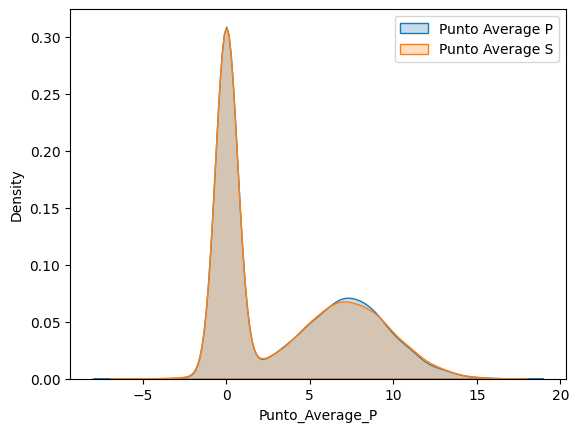

In [12]:
columnas = ['Punto Average P','Punto Average S']
for i, col in enumerate(punto_averages.columns):
    sns.kdeplot(punto_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

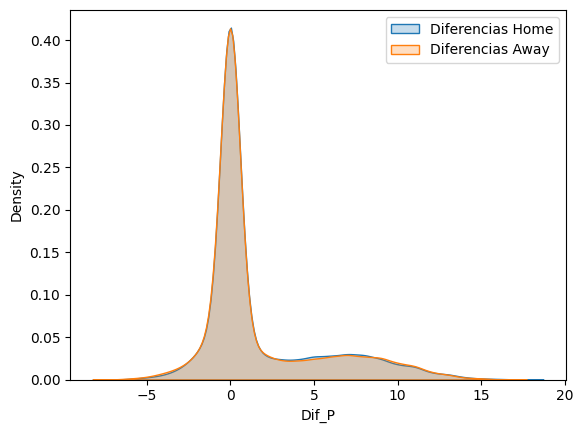

In [13]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

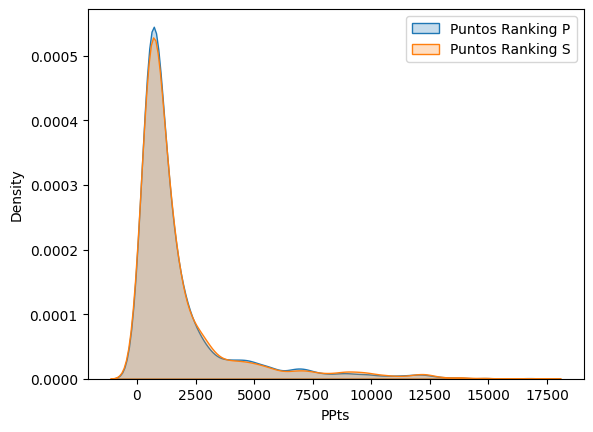

In [14]:
columnas = ['Puntos Ranking P','Puntos Ranking S']
for i, col in enumerate(puntos_rankings.columns):
    sns.kdeplot(puntos_rankings[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

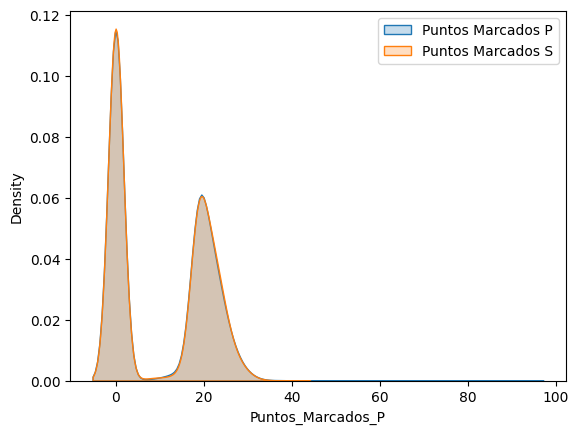

In [15]:
columnas = ['Puntos Marcados P','Puntos Marcados S']
for i, col in enumerate(puntos_marcados.columns):
    sns.kdeplot(puntos_marcados[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

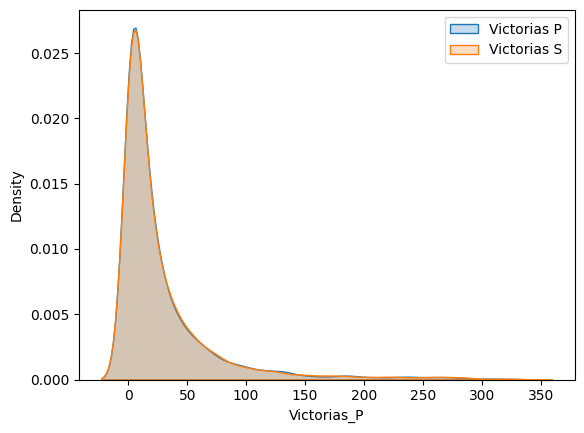

In [16]:
columnas = ['Victorias P','Victorias S']
for i, col in enumerate(victorias.columns):
    sns.kdeplot(victorias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

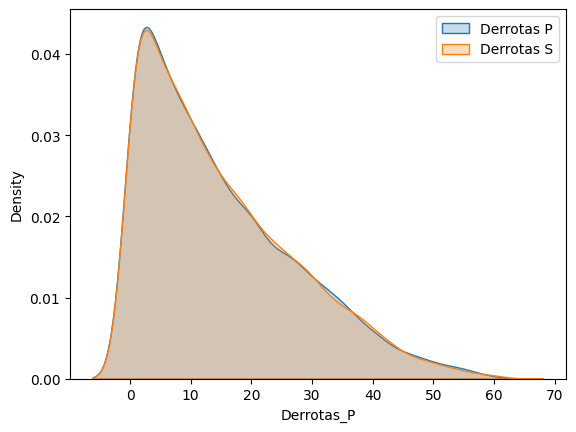

In [17]:
columnas = ['Derrotas P','Derrotas S']
for i, col in enumerate(derrotas.columns):
    sns.kdeplot(derrotas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [25]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Punto_Average_P,Punto_Average_S,Dif_P,Dif_P,Puntos_Marcados_P,Puntos_Marcados_S,Victorias_P,Derrotas_P,Victorias_S,Derrotas_S,PPts,SPts,PRank,SRank
0,0.26087,0.238095,0.276596,0.276596,0.0,0.0,0.0,0.0,0.0,0.0,0.039823,0.088201,0.038869,0.013139
1,0.26087,0.238095,0.276596,0.276596,0.0,0.0,0.0,0.0,0.0,0.0,0.120944,0.023422,0.007067,0.078102
2,0.26087,0.238095,0.276596,0.276596,0.0,0.0,0.0,0.0,0.0,0.0,0.050914,0.096460,0.026148,0.010219
3,0.26087,0.238095,0.276596,0.276596,0.0,0.0,0.0,0.0,0.0,0.0,0.027316,0.017404,0.061484,0.104380
4,0.26087,0.238095,0.276596,0.276596,0.0,0.0,0.0,0.0,0.0,0.0,0.029381,0.015103,0.056537,0.117518


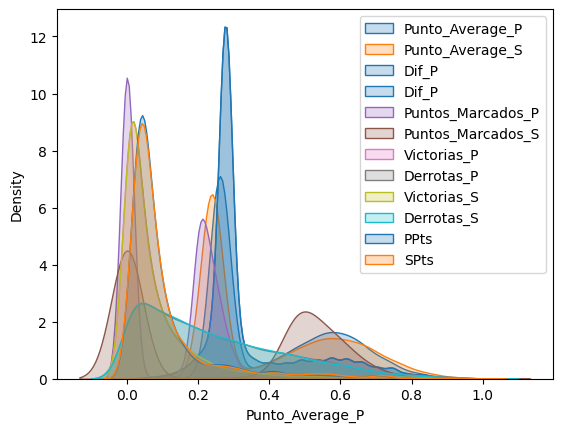

In [16]:
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [26]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([tenistaP, tenistaS]).T)
equipos_encoded.shape

(8636, 1249)

In [27]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.concatenate((features_normalized_dataframe[columnas_features].values,equipos_encoded), axis=1)

In [28]:
predictores.shape

(8636, 1265)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [29]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.20, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (6908, 1265) (6908,)
Test set: (1728, 1265) (1728,)


### Definición y construcción del modelo

In [30]:
def get_modelo_regresion():
    model = LogisticRegression(max_iter=3000, solver='sag')
    return model

def get_modelo_random_forest():
    model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=4, criterion='log_loss')
    return model

def get_modelo_svc():
    model = SVC(kernel='linear', C=0.5, gamma='scale', probability=True)
    return model

def get_modelo_gbm(): ##mejores resultados pero tarda en entrenar
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)  
    return model

def get_modelo_decision_tree():
    model = DecisionTreeClassifier(criterion="log_loss",max_depth=13, random_state=42) 
    return model

def get_modelo_knn(): ##mejor recall en empates
    model = KNeighborsClassifier(n_neighbors=47, metric="minkowski", weights='uniform')
    return model

def get_modelo_naive_bayes():
    #model = GaussianNB()
    model = MultinomialNB()
    return model

model = get_modelo_gbm()

### Entrenamiento del modelo

In [31]:
model.fit(features_train, target_train)
#iteraciones=4
#historial_entrenamiento=model.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

## -Evaluación del modelo

### Evolución del modelo

In [32]:
target_pred = model.predict(features_test)
accuracy = accuracy_score(target_test, target_pred)
recal = recall_score(target_test, target_pred, average=None)
recal_total = recall_score(target_test, target_pred, average='macro')
precision = precision_score(target_test, target_pred, average=None)
precision_total = precision_score(target_test, target_pred, average='macro')
conf_matrix = confusion_matrix(target_test, target_pred)
print("Accuracy del modelo:", accuracy)
print("Recall del modelo:", recal)
print("Recall del modelo:", recal_total)
print("Precision del modelo:", precision)
print("Precision del modelo:", precision_total)
print("Matriz de Confusión:")
print(conf_matrix)

Accuracy del modelo: 0.7222222222222222
Recall del modelo: [0.70330969 0.74036281]
Recall del modelo: 0.721836252231389
Precision del modelo: [0.72208738 0.72234513]
Precision del modelo: 0.7222162556920697
Matriz de Confusión:
[[595 251]
 [229 653]]


ValueError: The number of FixedLocator locations (85), usually from a call to set_ticks, does not match the number of labels (7).

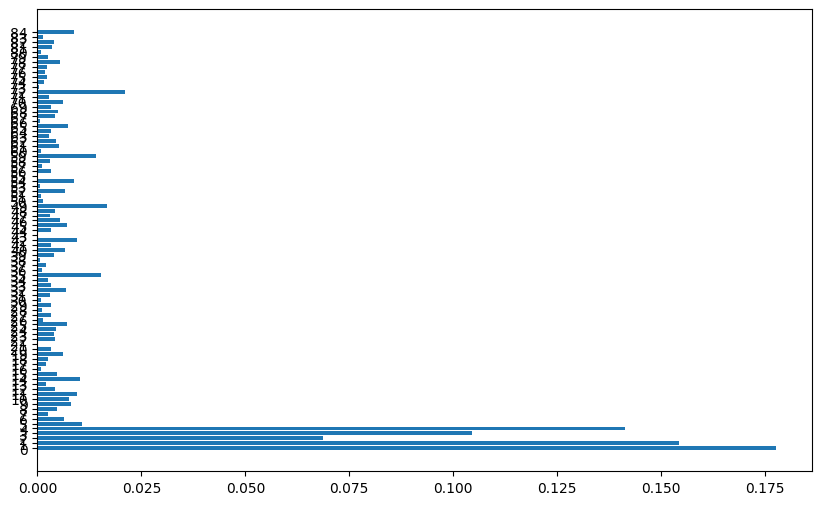

In [273]:
importances = model.feature_importances_

# Obtener nombres de las características
nombres_caracteristicas = ['GAH','GAA','RH','GH','GA','HT','AT']

# Crear un gráfico de barras para visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), nombres_caracteristicas)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las características en Random Forest')
plt.show()

## - Predicción real de un partido

In [142]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Real Madrid'
AT='Osasuna'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [143]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 80)

In [144]:
datos_partido = np.array([
    gol_average_home, gol_average_away,
    dif_home, dif_away,
    rojas_home, rojas_away
]).reshape(1, -1)
datos_partido = scale.transform(datos_partido)
datos_partido.shape

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(1, 6)

In [145]:
predictores = np.concatenate((datos_partido, equipos_encoded), axis=1)
predictores.shape

(1, 86)

### Predicción del valor objetivo

In [146]:
pred1 = model.predict_proba(predictores)
pred1

array([[0.12339029, 0.19494218, 0.68166753]])

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [147]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [148]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [149]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

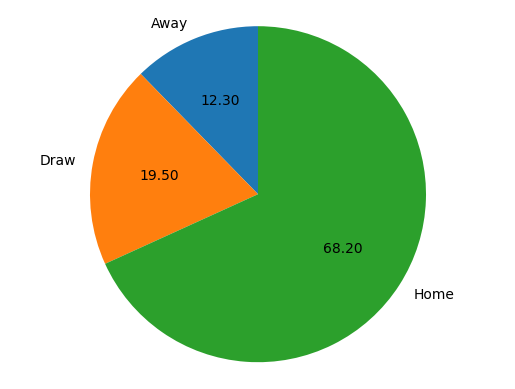

In [150]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()